# Resolving the G1-S artifact

Adding a +1 offset to the genome deconvolution handles the initial issue of small counts near zero creating a spike in the smoothing transition from G1 to S/G2M. There still appears to be an elevated occupancy in G1 across the entire genome that isn't fully understood.



In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1566]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 3
span = (20000, 20300)
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)

Adding a deconvolution offset to G: 1


In [1585]:
def plot_G_img_data(G_img_data):
    fig, axs = plt.subplots(8, 2, figsize=(3, 6))
    axs = np.array(axs).T.flatten()
    for i in range(len(tps)):
        ax = axs[i]
        ax.imshow(G_img_data[i],
              origin='lower', aspect='auto', vmin=1, vmax=5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylabel(f"{tps[i]}'")
    plt.subplots_adjust(hspace=0.5)


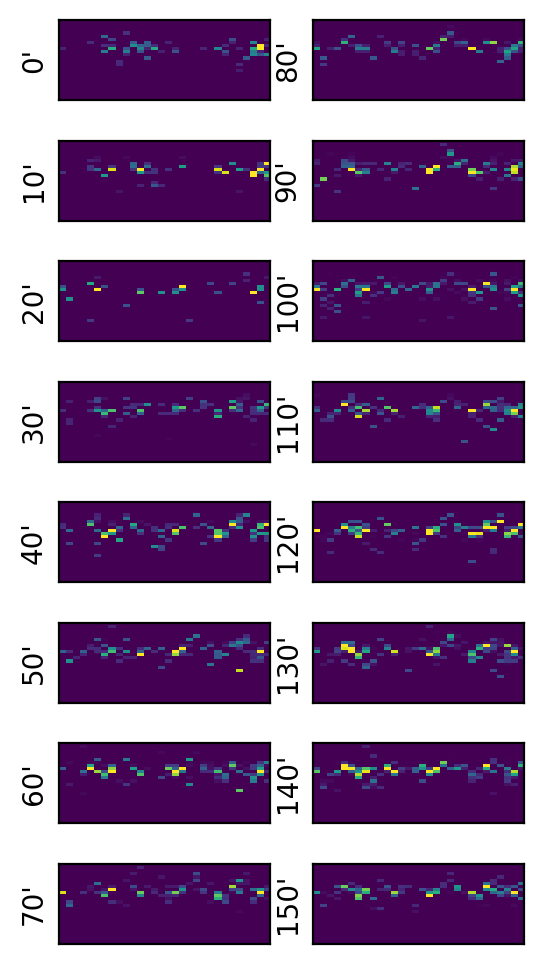

In [1586]:
G1_img_data = genome_deconvolution.combined_model.chrom1_model.deconv_hist_unflattened
plot_G_img_data(G1_img_data)

In [1583]:
def plot_deconvolved(genome_deconvolution):
    
    t_indices = genome_deconvolution.config1.get_Hpositions_for_branch('t')
    i_indices = genome_deconvolution.config1.get_Hpositions_for_branch('i')

    f = genome_deconvolution.combined_model.deconvolved_f_value.copy()

    G1_img_data = genome_deconvolution.combined_model.chrom1_model\
        .deconv_hist_unflattened+1
    G2_img_data = genome_deconvolution.combined_model.chrom2_model\
        .deconv_hist_unflattened+1

    plt.figure(figsize=(9, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(G1_img_data.reshape((G1_img_data.shape[0], -1)).T, aspect='auto')
    plt.ylim(60, 110)

    plt.subplot(1, 4, 2)
    plt.imshow(G1_img_data.reshape((G1_img_data.shape[0], -1)).T, aspect='auto')
    plt.ylim(60, 110)

    plt.subplot(1, 4, 3)
    plt.imshow(f[i_indices].T, interpolation='none', aspect='auto')
    plt.ylim(60, 110)

    plt.subplot(1, 4, 4)
    plt.imshow(f[t_indices].T, interpolation='none', aspect='auto')
    plt.ylim(60, 110)


def plot_f_genome_deconvolution_nuc_reads(genome_deconvolution):
    
    shp = genome_deconvolution.combined_model.deconvolved_f_value.shape
    t_indices = genome_deconvolution.config1.get_Hpositions_for_branch('t')
    i_indices = genome_deconvolution.config1.get_Hpositions_for_branch('i')
    
    f_imgs = genome_deconvolution.combined_model.\
        deconvolved_f_value.reshape((shp[0], 26, -1))
    nuc_reads = f_imgs[:, 12:18, :].sum(axis=1).T

    plt.figure(figsize=(9, 2))
    plt.subplot(1, 3, 1)
    plt.imshow(nuc_reads[:, i_indices], aspect='auto')
    plt.yticks([])
    plt.title("Initial")
    
    plt.subplot(1, 3, 2)
    plt.imshow(nuc_reads[:, t_indices], aspect='auto')
    plt.yticks([])
    plt.title("Top")
    
    plt.subplot(1, 3, 3)
    plt.plot(nuc_reads[:, i_indices].sum(axis=0), label="Initial")
    plt.plot(nuc_reads[:, t_indices].sum(axis=0), label="Top")
    plt.legend()


def plot_deconvolved_f_curve(genome_deconvolution, index):

    f = genome_deconvolution.combined_model.deconvolved_f_value.copy()
    
    t_indices = genome_deconvolution.config1.get_Hpositions_for_branch('t')
    i_indices = genome_deconvolution.config1.get_Hpositions_for_branch('i')
    
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 3, 1)
    model = genome_deconvolution.combined_model
    predicted_G1 = model.H1 @ f
    predicted_G2 = model.H2 @ f
    
    plt.plot(model.G1[:, index], label='G1', c='red')
    plt.plot(predicted_G1[:, index], label='predicted G1', c='red', ls='dotted')
    
    plt.plot(model.G2[:, index], label='G2', c='blue')
    plt.plot(predicted_G2[:, index], label='predicted G2', c='blue', ls='dotted')
        
    plt.title("Example Raw")
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(f[t_indices, index], label='Top')
    plt.plot(f[i_indices, index], label="Initial")
    plt.title("Example deconvolution")
    plt.legend()
    
    plt.subplot(1, 3, 3)
    
    plt.plot(f[t_indices].mean(axis=1), label="Top")
    plt.plot(f[i_indices].mean(axis=1), label="Initial")
    
    plt.title("Sum")
    plt.legend()

    # Removing mirroring helps in creating a smooth curve... 
    # Now there is the effect of doubling
    # Maybe this is better, but there is still an artifact around the CG1 to S seam
    # 
    # Probably still related to the same recovery-S-G2M scheme
    # It's worth trying a deconvolution with the new model


In [1593]:
genome_deconvolution.combined_model.deconvolve(gamma=0.4)

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.4
Deconvolving bin size: 10x10
of G shape: (31, 780)
Deconvolving with gamma=0.4
0/780 - 00:00:00.068
500/780 - 00:00:21.967
Deconvolved in : 00:00:35.772
The fitting norm is 1.32, the smoothing norm is: 0.00


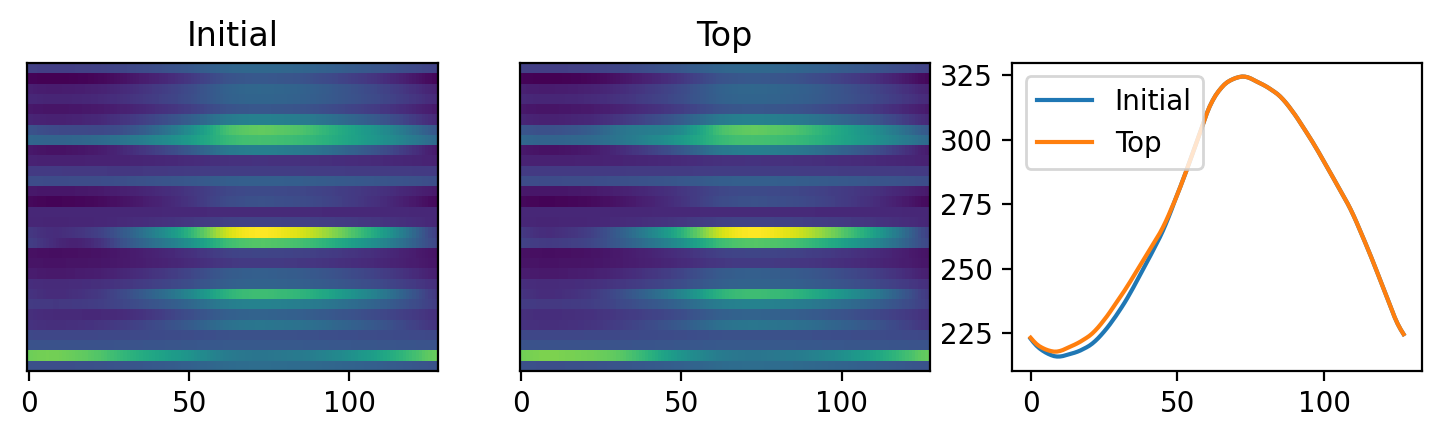

In [1594]:
plot_f_genome_deconvolution_nuc_reads(genome_deconvolution)

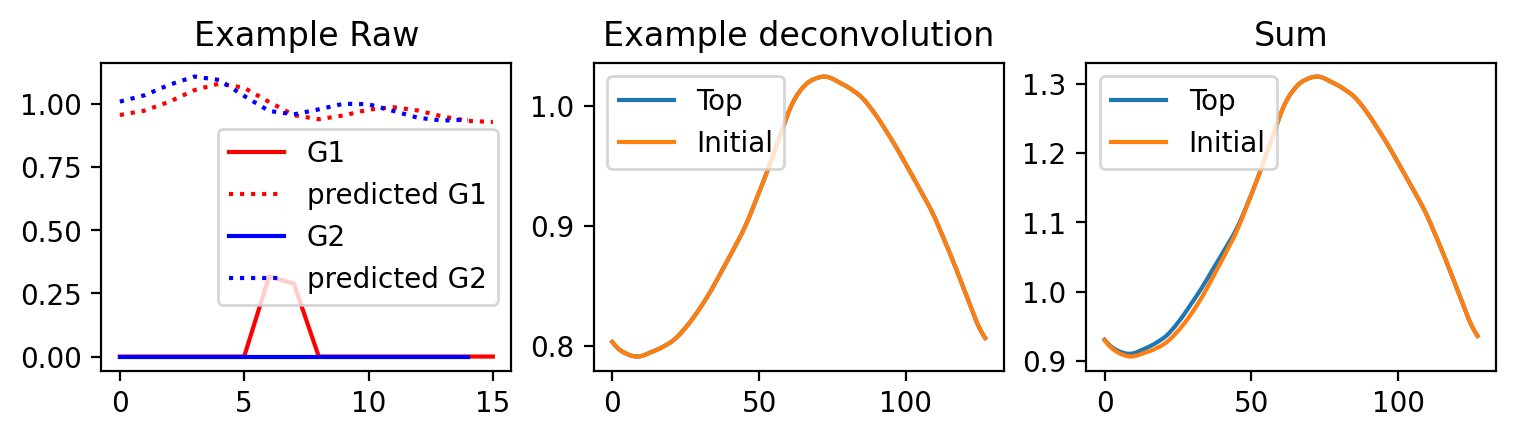

In [1597]:
plot_deconvolved_f_curve(genome_deconvolution, 230)

In [1605]:
f = genome_deconvolution.combined_model.deconvolved_f_value
f_imgs = f.reshape((178, 26, -1))

for i in range(len(f_imgs)):
    plt.figure(figsize=(3, 2))
    
    f_norm = f_imgs[i] / f_imgs[i].sum() * 1000
    
    plt.imshow(f_norm, origin='lower', aspect='auto', cmap='magma_r', vmin=1, vmax=5)
    plt.title(f"{i}/{len(f_imgs)-1}")
    plt.xticks([])
    plt.yticks([])
    plt.subplots_adjust(top=0.85)
    plt.savefig(f'output/tmp/f_{i}.png')
    plt.close()


def show_gif(gif_path):
    from IPython.display import Image
    import time

    gif_url = f"{gif_path}?{time.time()}" # bypass cached image
    display(Image(data=open(gif_path,'rb').read(), format='png'))
        
def create_animation(indices, gif_save_path):
    from PIL import Image

    frames_dir = 'output/tmp/'
    frame_files = []

    for animation_index in indices:
        frame_file = f'{frames_dir}/f_{animation_index}.png'
        frame_files.append(frame_file)

    frames = [Image.open(frame) for frame in frame_files]
    frames[0].save(gif_save_path, format='GIF', append_images=frames[1:], save_all=True, 
    duration=30, loop=1)
t_gif_path = 'output/tmp/animated_t.gif'
create_animation(t_indices, t_gif_path)

i_gif_path = 'output/tmp/animated_i.gif'
create_animation(i_indices, i_gif_path)